# Census Block Population Data Exploration

This notebook loads and processes the 2020 Census population data for Travis County.

We need population counts at the census block level, the smallest geographic unit the Census reports. These counts become the weights we use to split vote totals when a precinct straddles two congressional districts.

**Why census blocks?** Because land area is a bad proxy for where voters actually live. Census blocks tell us where people actually are.

In [2]:
import pandas as pd
import zipfile
import os

with zipfile.ZipFile('../data/raw/census/tx2020.pl.zip', 'r') as z:
    z.extractall('../data/raw/census/')

print("Files extracted successfully")
print(os.listdir('../data/raw/census/'))

Files extracted successfully
['tx2020.pl.zip', 'tx000022020.pl', '.gitkeep', 'tx000032020.pl', 'tx000012020.pl', 'txgeo2020.pl']


## Step 2 — Load the geographic header file and filter to Travis County

The geographic header file (txgeo2020.pl) tells us what each row represents geographically. We filter to two conditions:
- COUNTY == 453 (Travis County's FIPS code)
- SUMLEV == 750 (block level — the most granular geography available)

LOGRECNO is the record number that links this file to the population counts file.
Note: the long list of column names above is required because the raw file has no headers of its own.

In [4]:
# Read the geographic header file
# This file tells us the geography of each row (state, county, tract, block)
geo_headers = [
    'FILEID', 'STUSAB', 'SUMLEV', 'GEOVAR', 'GEOCOMP', 'CHARITER', 'CIFSN', 'LOGRECNO',
    'GEOID', 'GEOCODE', 'REGION', 'DIVISION', 'STATE', 'STATENS', 'COUNTY', 'COUNTYCC',
    'COUNTYNS', 'COUSUB', 'COUSUBCC', 'COUSUBNS', 'SUBMCD', 'SUBMCDCC', 'SUBMCDNS',
    'ESTATE', 'ESTATECC', 'ESTATENS', 'CONCIT', 'CONCITCC', 'CONCITNS', 'PLACE',
    'PLACECC', 'PLACENS', 'TRACT', 'BLKGRP', 'BLOCK', 'AIANHH', 'AIHHTLI', 'AIANHHFP',
    'AIANHHCC', 'AIANHHNS', 'AITS', 'AITSCC', 'AITSFP', 'AITSNS', 'TTRACT', 'TBLKGRP',
    'ANRC', 'ANRCCC', 'ANRCNS', 'CBSA', 'MEMI', 'CSA', 'METDIV', 'NECTA', 'NMEMI',
    'NECTADIV', 'CNECTA', 'CBSAPCI', 'NECTAPCI', 'UA', 'UATYPE', 'UR', 'CD116',
    'CD118', 'CD119', 'CD120', 'CD121', 'SLDU18', 'SLDU22', 'SLDU24', 'SLDL18',
    'SLDL22', 'SLDL24', 'VTD', 'VTDI', 'ZCTA', 'SDELM', 'SDSEC', 'SDUNI', 'PUMA',
    'AREALAND', 'AREAWATR', 'BASENAME', 'NAME', 'FUNCSTAT', 'GCUNI', 'POP100',
    'HU100', 'INTPTLAT', 'INTPTLON', 'LSADC', 'PARTFLAG', 'RESERVE2', 'RESERVE3',
    'RESERVE4', 'MSACSA', 'BEALE', 'NMEMI2', 'UACE', 'CBSATYPE'
]

geo = pd.read_csv('../data/raw/census/txgeo2020.pl', 
                  sep='|', 
                  header=None, 
                  names=geo_headers,
                  dtype=str,
                  low_memory=False)

print(f"Total rows: {len(geo)}")

# Filter to Travis County (FIPS 453) and block level (SUMLEV 750)
travis_blocks = geo[(geo['COUNTY'] == '453') & (geo['SUMLEV'] == '750')]
print(f"Travis County blocks: {len(travis_blocks)}")
travis_blocks[['LOGRECNO', 'COUNTY', 'TRACT', 'BLOCK', 'POP100']].head(10)

Total rows: 943920
Travis County blocks: 16906


,LOGRECNO,COUNTY,TRACT,BLOCK,POP100
869787,0869788,453,000101,1000,1000
869788,0869789,453,000101,1001,1001
869789,0869790,453,000101,1002,1002
869790,0869791,453,000101,1003,1003
869791,0869792,453,000101,1004,1004
869792,0869793,453,000101,1005,1005
869793,0869794,453,000101,1006,1006
869794,0869795,453,000101,1007,1007
869795,0869796,453,000101,1008,1008
869796,0869797,453,000101,1009,1009


## Step 3 — Load the population counts file

The actual population numbers live in a separate file (tx000012020.pl). 
Column 4 is the record number that links to the geography file. 
Column 5 is the total population count for each block.

In [5]:
# Read the population table (table 1)
# This contains the actual population counts
pop = pd.read_csv('../data/raw/census/tx000012020.pl',
                  sep='|',
                  header=None,
                  dtype=str,
                  low_memory=False)

print(f"Shape: {pop.shape}")
print(pop.head(3))

Shape: (943920, 149)
    0   1    2   3        4         5         6         7        8       9    \
0  PLST  TX  000  01  0000001  29145505  24011767  14609365  3552997  278948   
1  PLST  TX  000  01  0000002     57922     54327     34922    11577     357   
2  PLST  TX  000  01  0000003     18610     14756     10909      237     220   

   ... 139  140  141  142 143 144 145 146 147 148  
0  ...   0  581  305  203  30  21  16   6  58  58  
1  ...   0    2    0    2   0   0   0   0   3   3  
2  ...   0    0    0    0   0   0   0   0   0   0  

[3 rows x 149 columns]


## Step 4 — Join population counts to geography and validate

Links the population file to the geography file using LOGRECNO as the shared key.
Sanity check: Travis County's total population should be approximately 1.29 million based on the 2020 Census. If the number is way off, something went wrong in the join.

In [6]:
# The key columns we need are:
# Column 4: LOGRECNO (links to geo file)
# Column 5: P0010001 (total population)

pop_clean = pop[[4, 5]].copy()
pop_clean.columns = ['LOGRECNO', 'total_pop']
pop_clean['total_pop'] = pd.to_numeric(pop_clean['total_pop'], errors='coerce')

# Now join to the Travis County blocks from the geo file
travis_blocks_reset = travis_blocks.reset_index()
travis_pop = travis_blocks_reset.merge(pop_clean, on='LOGRECNO', how='left')

print(f"Travis County blocks with population: {len(travis_pop)}")
print(f"Total Travis County population: {travis_pop['total_pop'].sum():,.0f}")
travis_pop[['COUNTY', 'TRACT', 'BLOCK', 'total_pop']].head(10)

Travis County blocks with population: 16906
Total Travis County population: 1,290,188


,COUNTY,TRACT,BLOCK,total_pop
0,453,000101,1000,50
1,453,000101,1001,0
2,453,000101,1002,54
3,453,000101,1003,61
4,453,000101,1004,205
5,453,000101,1005,96
6,453,000101,1006,58
7,453,000101,1007,76
8,453,000101,1008,124
9,453,000101,1009,40


## Step 5 — Save the processed population data

Saves a clean, filtered file with just the Travis County blocks and their population counts. Note: this file is excluded from GitHub (too large) but can be regenerated by running this notebook from the top.

In [7]:
# Save Travis County block population data
travis_pop[['COUNTY', 'TRACT', 'BLOCK', 'LOGRECNO', 'total_pop']].to_csv(
    '../data/processed/travis_census_blocks_2020.csv', 
    index=False
)

print("Saved to /data/processed/travis_census_blocks_2020.csv")

Saved to /data/processed/travis_census_blocks_2020.csv


## Step 6 — Save data source notes

Writes a reference document to /data/raw/census/census_notes.md with source URLs, field names, and key facts about the data. 
Read this file if you need to re-download or understand the raw data.

In [8]:
notes = """# Census Data Notes

## 2020 Census P.L. 94-171 Redistricting File — Texas
- **Source:** U.S. Census Bureau
- **URL:** https://www2.census.gov/programs-surveys/decennial/2020/data/01-Redistricting_File--PL_94-171/Texas/
- **File:** tx2020.pl.zip (95MB)
- **Download date:** May 2026
- **Key file:** tx000012020.pl (population table), txgeo2020.pl (geography)
- **Population field:** Column 5 (P0010001) = total population
- **Geography field:** LOGRECNO links population table to geo file

## Travis County Summary
- **FIPS code:** 453
- **Summary level for blocks:** SUMLEV = 750
- **Total blocks:** 16,906
- **Total population:** 1,290,188
- **Processed file:** /data/processed/travis_census_blocks_2020.csv

## Notes
- Population counts are exact 2020 Census counts (not estimates)
- Some blocks have zero population (commercial areas, parks, etc.)
- This data was designed specifically for redistricting work
"""

with open('../data/raw/census/census_notes.md', 'w') as f:
    f.write(notes)

print("census_notes.md saved")

census_notes.md saved


## Step 7 — Inspect the TLC block population file

The Texas Legislative Council provides a separate block-level file that includes both population counts and demographic breakdowns. 
This cell confirms what is inside the zip before extracting.

In [9]:
import zipfile
with zipfile.ZipFile('../data/raw/census/Blocks_Pop.zip', 'r') as z:
    print(z.namelist())

['Blocks_Pop.txt']


## Step 8 — Inspect the TLC block geometry file

The block geometry file contains the actual map shapes for each census block.
We need these shapes to do the spatial join in notebook 03.
This cell confirms the shapefile components are all present.

In [10]:
with zipfile.ZipFile('../data/raw/census/Blocks.zip', 'r') as z:
    print(z.namelist()[:10])

['Blocks.cpg', 'Blocks.dbf', 'Blocks.prj', 'Blocks.sbn', 'Blocks.sbx', 'Blocks.shp', 'Blocks.shp.xml', 'Blocks.shx']


## Step 9 — Load the block geometry file

Loads the statewide Texas block shapefile. Note the CRS matches our 
boundary files from notebook 01 — no reprojection needed.
668,757 blocks statewide. We filter to Travis County in the next step.

In [11]:
import geopandas as gpd

# Load the blocks shapefile
blocks = gpd.read_file('zip://../data/raw/census/Blocks.zip!Blocks.shp')

print(f"Total blocks statewide: {len(blocks)}")
print(f"Columns: {list(blocks.columns)}")
print(f"CRS: {blocks.crs}")

Total blocks statewide: 668757
Columns: ['BG', 'State', 'CNTY', 'TRT', 'BLK', 'SCTBKEY', 'vtd', 'blkkey', 'CTBKEY', 'CNTYKEY', 'Shape_area', 'Shape_len', 'geometry']
CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


## Step 10 — Check the county field format

The CNTY field uses string values with leading zeros (e.g. '453' not 453). 
This matters for filtering — the wrong format returns zero results.

In [13]:
print(blocks['CNTY'].unique()[:20])
print(blocks['CNTY'].dtype)

['001' '023' '025' '027' '003' '005' '007' '009' '011' '013' '015' '017'
 '019' '021' '029' '031' '033' '035' '037' '039']
object


## Step 11 — Filter blocks to Travis County

Using the string value '453' (not numeric 453) to match the field format.
Should return 16,906 blocks.

In [14]:
travis_blocks_geo = blocks[blocks['CNTY'] == '453'].copy()
print(f"Travis County blocks: {len(travis_blocks_geo)}")

Travis County blocks: 16906


## Step 12 — Load the TLC population and demographics file

Extracts and loads Blocks_Pop.txt which contains population counts 
and demographic breakdowns for every Texas census block. Note: the file is comma-separated despite the .txt extension.

In [16]:
# Extract Blocks_Pop.zip
with zipfile.ZipFile('../data/raw/census/Blocks_Pop.zip', 'r') as z:
    z.extractall('../data/raw/census/')

# Load it
pop_txt = pd.read_csv('../data/raw/census/Blocks_Pop.txt', sep=',', dtype=str)
print(f"Columns: {list(pop_txt.columns)}")
print(pop_txt.head(3))

Columns: ['FID', 'BG', 'State', 'TRT', 'BLK', 'SCTBKEY', 'blkkey', 'CTBKEY', 'FIPS', 'FENAME', 'anglo', 'asian', 'hisp', 'total', 'vap', 'black', 'bh', 'nanglo', 'anglovap', 'hispvap', 'bhvap', 'blackvap', 'asianvap', 'nanglovap', 'Shape_Leng', 'Shape_Ar_1']
  FID BG State     TRT   BLK          SCTBKEY blkkey         CTBKEY FIPS  \
0   0  1    48  950100  1012  480019501001012     13  0019501001012  001   
1   1  1    48  950100  1013  480019501001013     14  0019501001013  001   
2   2  1    48  950100  1014  480019501001014     15  0019501001014  001   

     FENAME  ... bh nanglo anglovap hispvap bhvap blackvap asianvap nanglovap  \
0  ANDERSON  ...  1      5        7       0     1        1        0         2   
1  ANDERSON  ...  0      0       17       0     0        0        0         0   
2  ANDERSON  ...  2      3       10       0     1        1        0         2   

            Shape_Leng             Shape_Ar_1  
0  726.928055911000001  23857.378169999999955  
1  833.50763448

## Step 13 — Join population and demographics to block geometries

Merges the population counts onto the block shapes using SCTBKEY as the shared key. The result is a single file with both map shapes and population data for every Travis County block.

Sanity check: total population should match 1,290,188 from Step 4.
If it does, the join worked correctly.

In [17]:
# Filter population to Travis County using FIPS field
travis_pop_txt = pop_txt[pop_txt['FIPS'] == '453'].copy()
print(f"Travis County rows in population file: {len(travis_pop_txt)}")

# Join population to geometry on block key
travis_blocks_final = travis_blocks_geo.merge(
    travis_pop_txt[['SCTBKEY', 'total', 'anglo', 'asian', 'hisp', 'black']],
    on='SCTBKEY',
    how='left'
)

travis_blocks_final['total'] = pd.to_numeric(travis_blocks_final['total'], errors='coerce')

print(f"Joined blocks: {len(travis_blocks_final)}")
print(f"Total population: {travis_blocks_final['total'].sum():,.0f}")
travis_blocks_final[['CNTY', 'SCTBKEY', 'total', 'geometry']].head(5)

Travis County rows in population file: 16906
Joined blocks: 16906
Total population: 1,290,188


,CNTY,SCTBKEY,total,geometry
0,453,484530357003010,131,"POLYGON ((1206048.827 923478.865, 1206050.220 ..."
1,453,484530357003011,87,"POLYGON ((1206136.292 923782.540, 1206137.186 ..."
2,453,484530357003012,133,"POLYGON ((1206232.903 923975.518, 1206234.078 ..."
3,453,484530357003013,102,"POLYGON ((1206153.111 923178.918, 1206153.667 ..."
4,453,484530357003014,73,"POLYGON ((1206302.625 923949.211, 1206388.617 ..."


## Step 14 — Save the final Travis County blocks file

Saves the combined geometry and population data to /data/processed/travis_blocks_2020.gpkg.
This is the key input for notebook 03, the spatial intersection engine.

In [18]:
travis_blocks_final.to_file(
    '../data/processed/travis_blocks_2020.gpkg',
    driver='GPKG'
)

print("Saved to /data/processed/travis_blocks_2020.gpkg")

Saved to /data/processed/travis_blocks_2020.gpkg


## Step 15 — Visualize population density across Travis County

Heat map showing where people actually live. Dense areas appear dark red, sparse areas yellow. This illustrates why population-weighted interpolation matters — the yellow areas (farmland, parks) would distort results if we used land area instead of population to split votes.

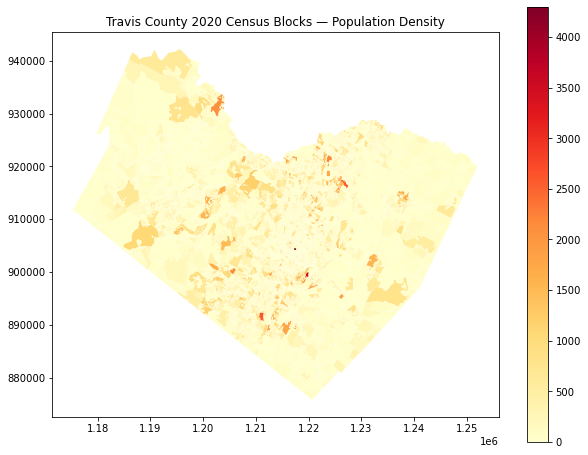

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

travis_blocks_final.plot(ax=ax, column='total', cmap='YlOrRd', 
                         edgecolor='none', legend=True)

ax.set_title('Travis County 2020 Census Blocks — Population Density')
plt.show()

## Step 16 — Update data source notes

Appends additional documentation to census_notes.md covering the TLC block geometry file and the final processed output. 
Important: Blocks.zip is too large for GitHub and must be downloaded manually — instructions are in census_notes.md.

In [20]:
additional_notes = """
## Census Block Geometries (TLC)
- **Source:** Texas Legislative Council Capitol Data Portal
- **URL:** https://data.capitol.texas.gov/dataset/2020-census-geography
- **File:** Blocks.zip (371MB — too large for GitHub, download manually)
- **Also download:** Blocks_Pop.zip (30MB — already in repo)
- **Instructions:** Download Blocks.zip, save to `/data/raw/census/`
- **Note:** Blocks.zip contains block geometries for all of Texas.
  Filter to Travis County using CNTY == '453'

## Processed Output
- **File:** `/data/processed/travis_blocks_2020.gpkg`
- **Contains:** 16,906 Travis County census blocks with geometry and 
  population counts (total, anglo, asian, hisp, black)
- **This file is in the repo** — you only need Blocks.zip if you want 
  to re-run the processing from scratch
"""

# Append to existing census_notes.md
with open('../data/raw/census/census_notes.md', 'a') as f:
    f.write(additional_notes)

print("census_notes.md updated")

census_notes.md updated
